# Notebook 08 - Experimento 4: Robustez estacional del modelo global

## Pregunta que responde
¿Generaliza igual el modelo a LECA1 en todas las estaciones del año,
o hay estaciones donde la transferencia entre plantas falla más?

## Objetivo
Evaluar la robustez estacional de un modelo global entrenado en otras plantas al aplicarlo sobre LECA1 en distintas epocas del año.
No se busca prediccion futura, sino evaluación de consistencia temporal.

## Partición

| Split | Plantas | Periodo |
|---|---|---|
| Train | Afrisol + E03 | ene 2022 - sep 2023 |
| Validacion | Afrisol + E03 | oct-nov 2023 |
| Test Invierno | LECA1 | dic 2022 + ene-feb 2023 |
| Test Primavera | LECA1 | mar-may 2023 |
| Test Verano | LECA1 | jun-ago 2023 |
| Test Otono | LECA1 | sep-nov 2023 |

## Puntos a tener en cuenta
- Se compara el comportamiento con *lag* vs. sin *lag* en cada estación.
- Los *lags* reducen la variabilidad estacional: parte de esa variabilidad
  se debe a dependencia temporal, no solo a condiciones externas.
- Ridge, al ser lineal, no capta cambios de régimen estacional.


### 1. Configuración de rutas e importaciones


In [2]:
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"

from src.data import add_nominal_power_and_target
from src.evaluation import compute_metrics
from src.features import FeatureConfig, build_features, get_feature_columns
from src.models import get_baseline_models

warnings.filterwarnings("ignore", category=FutureWarning)
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga de datos y definición de periodos estacionales


In [3]:
df_all = pd.read_csv(DATA_DIR / "df_all_unificado.csv", parse_dates=["timestamp"])

NOMINAL_POWER = {"E03": 12.4, "Afrisol": 12.0, "LECA1": 19.53}
df_all = df_all.drop(columns=["power_pu", "p_nominal_kw"], errors="ignore")
df_all = add_nominal_power_and_target(df_all, NOMINAL_POWER)

SEASONS = {
    "Invierno":  {"start": "2022-12-01", "end": "2023-02-28"},
    "Primavera": {"start": "2023-03-01", "end": "2023-05-31"},
    "Verano":    {"start": "2023-06-01", "end": "2023-08-31"},
    "Otono":     {"start": "2023-09-01", "end": "2023-11-30"},
}

TRAIN_END = "2023-09-30"
VAL_START = "2023-10-01"
VAL_END   = "2023-11-30"

print("Estaciones de test definidas:")
for s, p in SEASONS.items():
    n = len(df_all[
        (df_all["id_planta"] == "LECA1") &
        (df_all["timestamp"] >= p["start"]) &
        (df_all["timestamp"] <= p["end"])
    ])
    print(f"  {s}: {p['start']} -> {p['end']} | {n:,} filas LECA1")


Estaciones de test definidas:
  Invierno: 2022-12-01 -> 2023-02-28 | 8,545 filas LECA1
  Primavera: 2023-03-01 -> 2023-05-31 | 8,628 filas LECA1
  Verano: 2023-06-01 -> 2023-08-31 | 8,734 filas LECA1
  Otono: 2023-09-01 -> 2023-11-30 | 8,641 filas LECA1


### 3. Ingeniería de variables - con lag y sin lag


In [4]:
config_lag = FeatureConfig(
    lag_steps_power=(1, 2, 4), lag_steps_radiation=(1, 2),
    rolling_windows_power=(4, 8), rolling_windows_radiation=(4,),
    add_interactions=True, add_daylight_flag=True,
    drop_na_after_features=True, one_hot_encode_plant=False,
)
config_nolag = FeatureConfig(
    lag_steps_power=(), lag_steps_radiation=(),
    rolling_windows_power=(), rolling_windows_radiation=(),
    add_interactions=True, add_daylight_flag=True,
    drop_na_after_features=True, one_hot_encode_plant=False,
)

TARGET = "power_pu"

df_lag   = build_features(df_all, config=config_lag).drop(columns=["Mes"], errors="ignore")
df_nolag = build_features(df_all, config=config_nolag).drop(columns=["Mes"], errors="ignore")

feat_lag   = get_feature_columns(df_lag)
feat_nolag = get_feature_columns(df_nolag)

print(f"Features con lag: {len(feat_lag)} | sin lag: {len(feat_nolag)}")


Features con lag: 32 | sin lag: 19


### 4. Partición train/validación y resumen del diseño


In [5]:
def get_train_val(df: pd.DataFrame, feat_cols: list):
    """Extrae train y validacion sobre Afrisol + E03."""
    train = df[
        df["id_planta"].isin(["Afrisol", "E03"]) &
        (df["timestamp"] <= TRAIN_END)
    ]
    val = df[
        df["id_planta"].isin(["Afrisol", "E03"]) &
        (df["timestamp"] >= VAL_START) &
        (df["timestamp"] <= VAL_END)
    ]
    return train[feat_cols], train[TARGET], val[feat_cols], val[TARGET]

X_tr_l, y_tr_l, X_v_l, y_v_l = get_train_val(df_lag,   feat_lag)
X_tr_n, y_tr_n, X_v_n, y_v_n = get_train_val(df_nolag, feat_nolag)

rows = [
    {"split": "train", "plantas": "Afrisol, E03", "inicio": "2022-01-01", "fin": TRAIN_END, "n_filas": len(X_tr_l)},
    {"split": "val",   "plantas": "Afrisol, E03", "inicio": VAL_START,   "fin": VAL_END,   "n_filas": len(X_v_l)},
]
for s, p in SEASONS.items():
    n = len(df_lag[
        (df_lag["id_planta"] == "LECA1") &
        (df_lag["timestamp"] >= p["start"]) &
        (df_lag["timestamp"] <= p["end"])
    ])
    rows.append({"split": f"test_{s}", "plantas": "LECA1", "inicio": p["start"], "fin": p["end"], "n_filas": n})

display(pd.DataFrame(rows))


,split,plantas,inicio,fin,n_filas
0,train,"Afrisol, E03",2022-01-01,2023-09-30,121882
1,val,"Afrisol, E03",2023-10-01,2023-11-30,11522
2,test_Invierno,LECA1,2022-12-01,2023-02-28,8545
3,test_Primavera,LECA1,2023-03-01,2023-05-31,8628
4,test_Verano,LECA1,2023-06-01,2023-08-31,8734
5,test_Otono,LECA1,2023-09-01,2023-11-30,8641


### 5. Entrenamiento y evaluación estacional
Los modelos se entrenan una sola vez sobre el conjunto global y se evaluan
independientemente sobre cada estación de LECA1, solo en horas de producción.


In [6]:
models_lag   = get_baseline_models(random_state=42)
models_nolag = get_baseline_models(random_state=42)

for name in models_lag:
    print(f"  Entrenando {name}...")
    models_lag[name].fit(X_tr_l, y_tr_l)
    models_nolag[name].fit(X_tr_n, y_tr_n)

all_results = []

for season, p in SEASONS.items():
    test_lag_s = df_lag[
        (df_lag["id_planta"] == "LECA1") &
        (df_lag["timestamp"] >= p["start"]) &
        (df_lag["timestamp"] <= p["end"])
    ].copy()
    test_nolag_s = df_nolag[
        (df_nolag["id_planta"] == "LECA1") &
        (df_nolag["timestamp"] >= p["start"]) &
        (df_nolag["timestamp"] <= p["end"])
    ].copy()

    for name in models_lag:
        for tipo, model, df_t, feats in [
            ("Con lags",  models_lag[name],   test_lag_s,   feat_lag),
            ("Sin lags",  models_nolag[name], test_nolag_s, feat_nolag),
        ]:
            if df_t.empty:
                continue
            y_true = df_t[TARGET].values
            y_pred = model.predict(df_t[feats])
            mask   = y_true > 0
            if mask.sum() < 20:
                continue
            metrics = compute_metrics(y_true[mask], y_pred[mask])
            all_results.append({"model": name, "tipo": tipo, "estacion": season, **metrics})

df_seasonal = pd.DataFrame(all_results)
print(f"Resultados calculados: {len(df_seasonal)} filas")
display(df_seasonal.sort_values(["estacion", "RMSE"]).reset_index(drop=True))


  Entrenando Ridge...
  Entrenando Random Forest...
  Entrenando ExtraTrees...
  Entrenando XGBoost...
  Entrenando LightGBM...
  Entrenando CatBoost...
  Entrenando MLP...
Resultados calculados: 56 filas


,model,tipo,estacion,MAE,RMSE,R2
0,MLP,Con lags,Invierno,0.020269,0.035250,0.982951
1,XGBoost,Con lags,Invierno,0.026214,0.041006,0.976928
2,ExtraTrees,Con lags,Invierno,0.026626,0.041657,0.976189
3,LightGBM,Con lags,Invierno,0.027064,0.042218,0.975544
4,Random Forest,Con lags,Invierno,0.026902,0.044549,0.972769
5,CatBoost,Con lags,Invierno,0.031360,0.046326,0.970553
6,Ridge,Con lags,Invierno,0.028898,0.046572,0.970239
7,ExtraTrees,Sin lags,Invierno,0.065788,0.087309,0.895406
8,Random Forest,Sin lags,Invierno,0.065280,0.087319,0.895382
9,MLP,Sin lags,Invierno,0.065377,0.089250,0.890705


### 6. RMSE por estación - con lag vs. sin lag


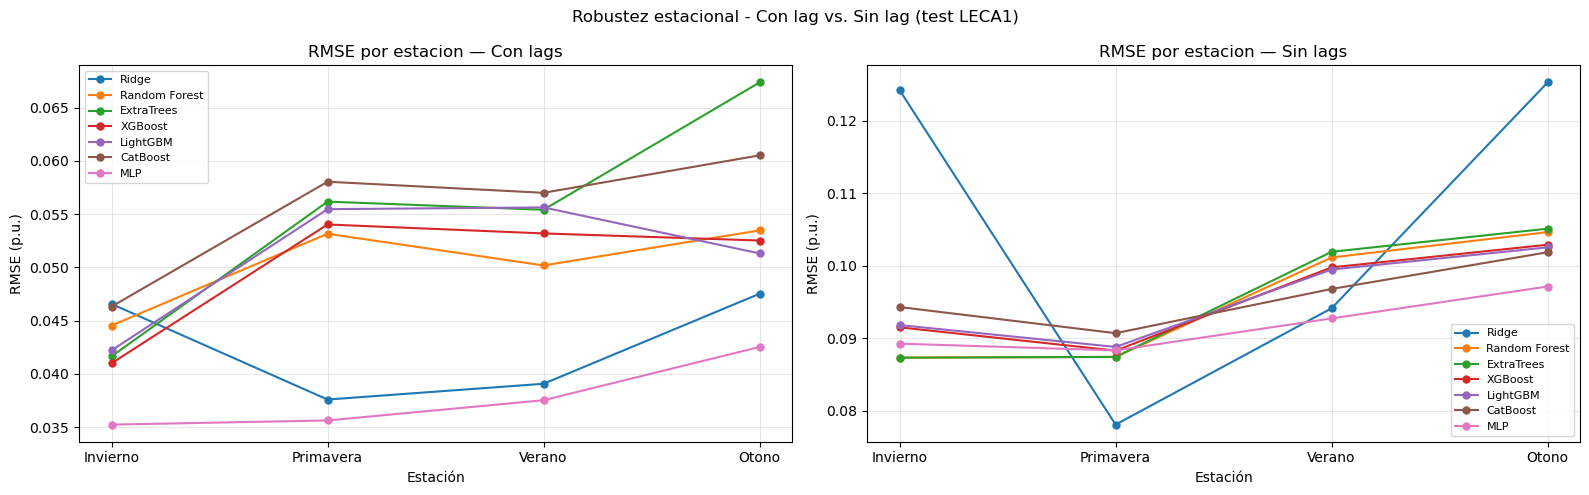

In [7]:
season_order = ["Invierno", "Primavera", "Verano", "Otono"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tipo in zip(axes, ["Con lags", "Sin lags"]):
    df_t = df_seasonal[df_seasonal["tipo"] == tipo]
    for model_name in df_t["model"].unique():
        df_m = (
            df_t[df_t["model"] == model_name]
            .set_index("estacion")
            .reindex(season_order)
        )
        ax.plot(season_order, df_m["RMSE"], marker="o", label=model_name, markersize=5)
    ax.set_title(f"RMSE por estacion — {tipo}")
    ax.set_xlabel("Estación")
    ax.set_ylabel("RMSE (p.u.)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Robustez estacional - Con lag vs. Sin lag (test LECA1)", fontsize=12)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "exp4_estacionalidad.png", dpi=150, bbox_inches="tight")
plt.show()


### 7. Variabilidad estacional por modelo
Un modelo con menor desviación típica del RMSE entre estaciones es más robusto frente a cambios de condiciones operativas a lo largo del año.


Variabilidad estacional (menor std = mas robusto):


,,mean,std,min,max,rango
model,tipo,,,,,
MLP,Con lags,0.0377,0.0033,0.0352,0.0425,0.0073
Random Forest,Con lags,0.0503,0.0041,0.0445,0.0535,0.0090
Ridge,Con lags,0.0427,0.0051,0.0376,0.0475,0.0099
XGBoost,Con lags,0.0502,0.0062,0.0410,0.0540,0.0130
LightGBM,Con lags,0.0512,0.0063,0.0422,0.0556,0.0134
CatBoost,Con lags,0.0555,0.0063,0.0463,0.0605,0.0142
ExtraTrees,Con lags,0.0552,0.0105,0.0417,0.0674,0.0257
MLP,Sin lags,0.0919,0.0040,0.0883,0.0971,0.0088
CatBoost,Sin lags,0.0959,0.0047,0.0907,0.1019,0.0112


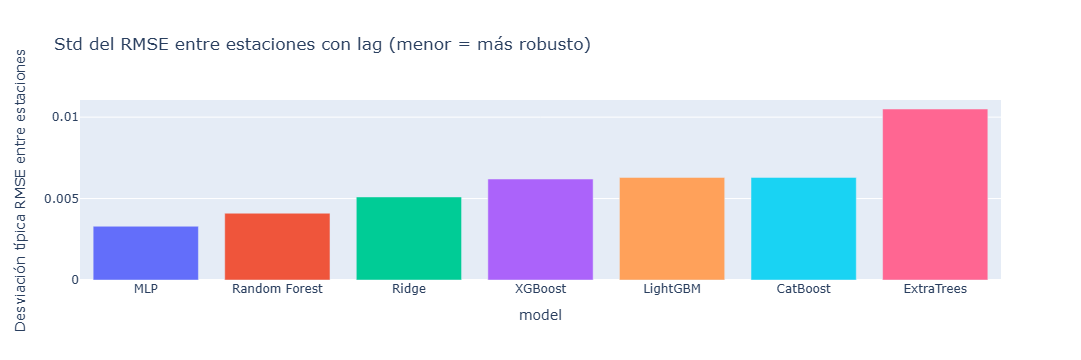

In [8]:
variability = (
    df_seasonal.groupby(["model", "tipo"])["RMSE"]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)
variability["rango"] = variability["max"] - variability["min"]
variability = variability.sort_values(["tipo", "rango"])

print("Variabilidad estacional (menor std = mas robusto):")
display(variability)

df_var = variability.reset_index()
fig = px.bar(
    df_var[df_var["tipo"] == "Con lags"].sort_values("std"),
    x="model", y="std", color="model",
    title="Std del RMSE entre estaciones con lag (menor = más robusto)",
    labels={"std": "Desviación típica RMSE entre estaciones"},
)
fig.update_layout(showlegend=False)
fig.show()


### 8. Error por hora del día en cada estación
Perfil horario del MAE para el mejor modelo de cada escenario,
desagregado por estación.


Mejor con lag: MLP | Mejor sin lag: MLP


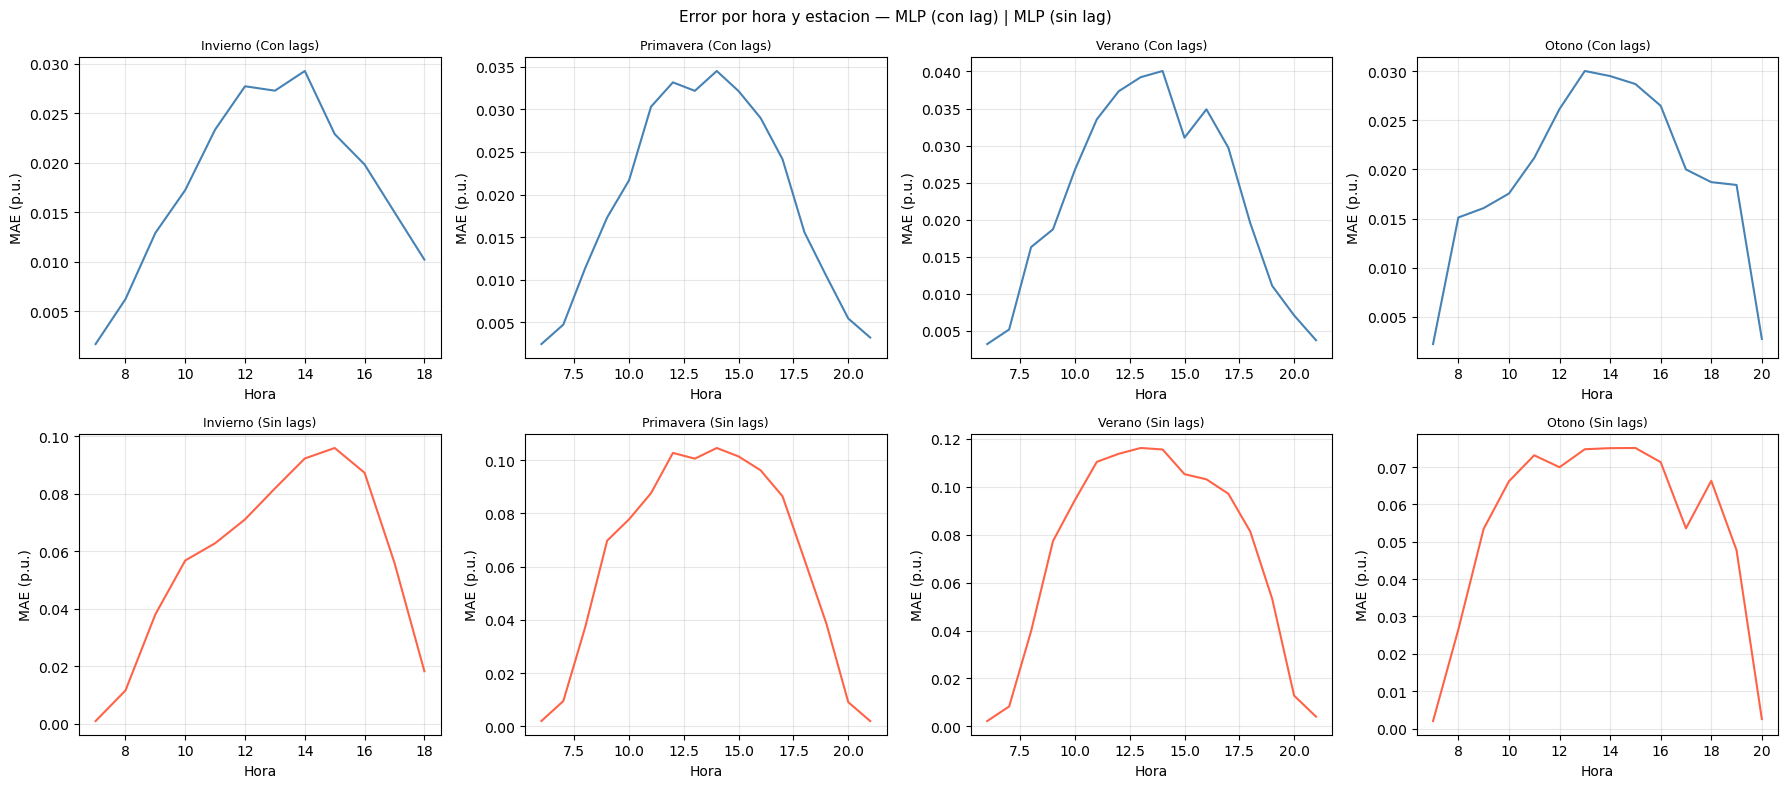

In [9]:
best_lag   = df_seasonal[df_seasonal["tipo"] == "Con lags"].groupby("model")["RMSE"].mean().idxmin()
best_nolag = df_seasonal[df_seasonal["tipo"] == "Sin lags"].groupby("model")["RMSE"].mean().idxmin()
print(f"Mejor con lag: {best_lag} | Mejor sin lag: {best_nolag}")

fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharey=False)

for row, (tipo, model_name, feat_cols, models_dict, color) in enumerate([
    ("Con lags", best_lag,   feat_lag,   models_lag,   "steelblue"),
    ("Sin lags", best_nolag, feat_nolag, models_nolag, "tomato"),
]):
    for col, season in enumerate(season_order):
        p = SEASONS[season]
        df_src = df_lag if tipo == "Con lags" else df_nolag
        df_s = df_src[
            (df_src["id_planta"] == "LECA1") &
            (df_src["timestamp"] >= p["start"]) &
            (df_src["timestamp"] <= p["end"])
        ].copy()
        if df_s.empty:
            continue
        df_s["y_pred"] = models_dict[model_name].predict(df_s[feat_cols])
        df_s["error"]  = (df_s[TARGET] - df_s["y_pred"]).abs()
        hourly = df_s[df_s[TARGET] > 0].groupby("hour")["error"].mean()
        axes[row][col].plot(hourly.index, hourly.values, color=color)
        axes[row][col].set_title(f"{season} ({tipo})", fontsize=9)
        axes[row][col].set_xlabel("Hora")
        axes[row][col].set_ylabel("MAE (p.u.)")
        axes[row][col].grid(alpha=0.3)

plt.suptitle(
    f"Error por hora y estacion — {best_lag} (con lag) | {best_nolag} (sin lag)",
    fontsize=11,
)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "exp4_error_hora_estacion.png", dpi=150, bbox_inches="tight")
plt.show()


### 9. Distribucion del error diario por estación
Diagramas de caja del MAE diario por modelo y estación para identificar
los días con errores más extremos.


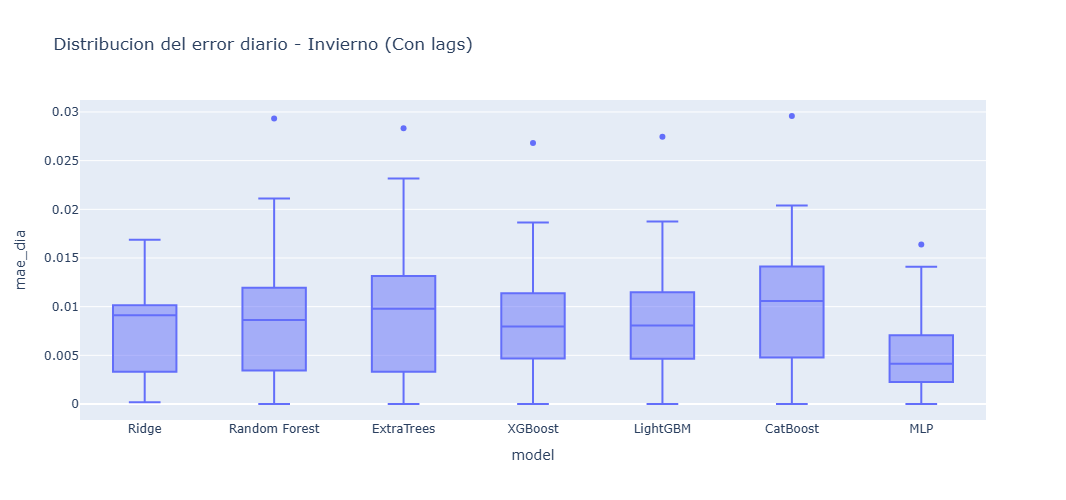

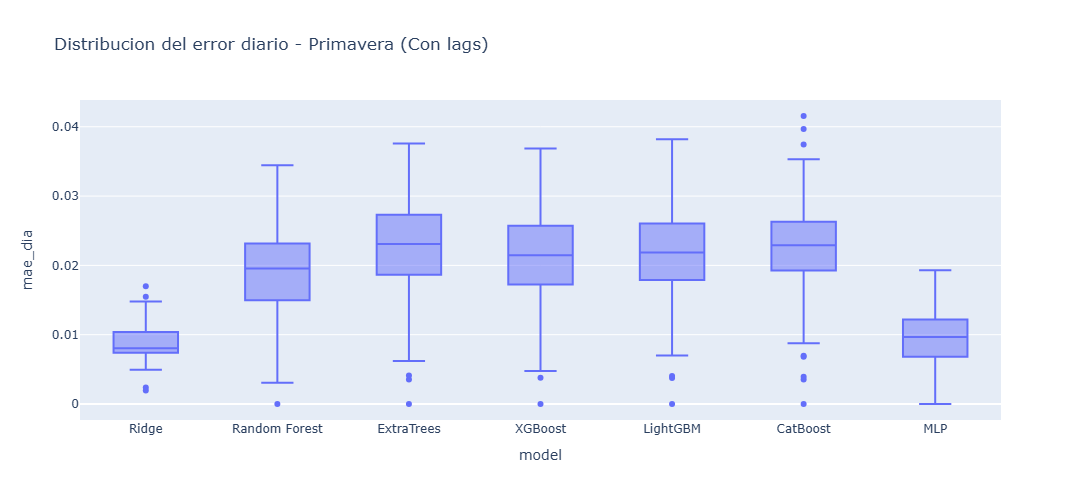

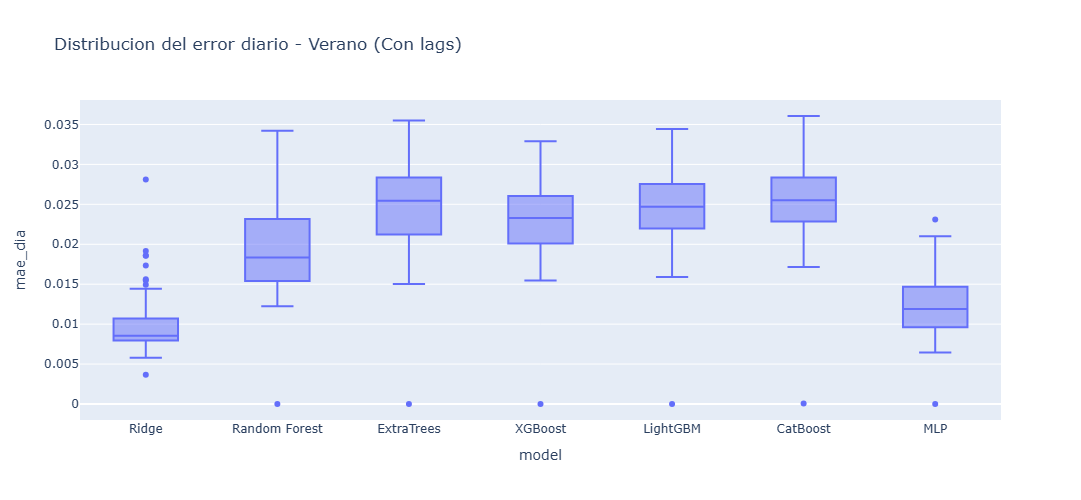

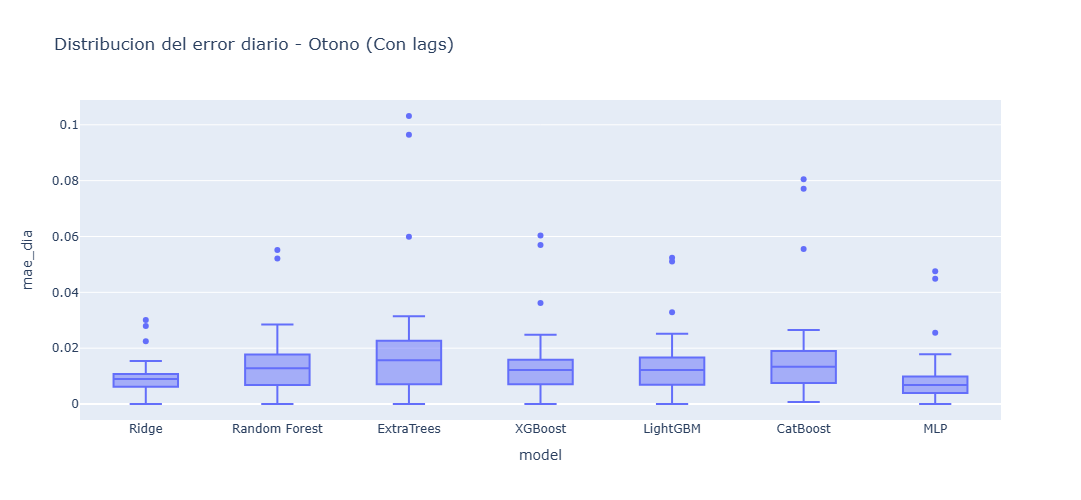

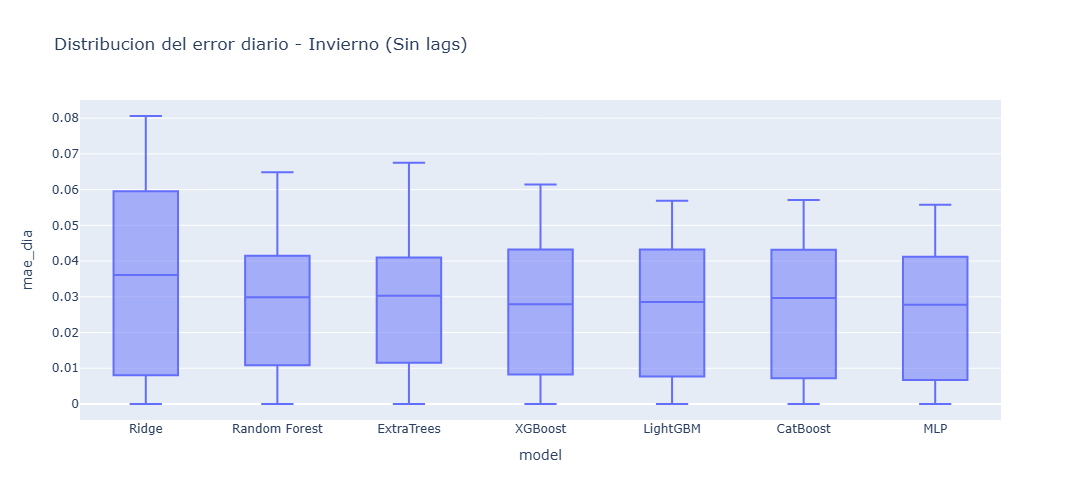

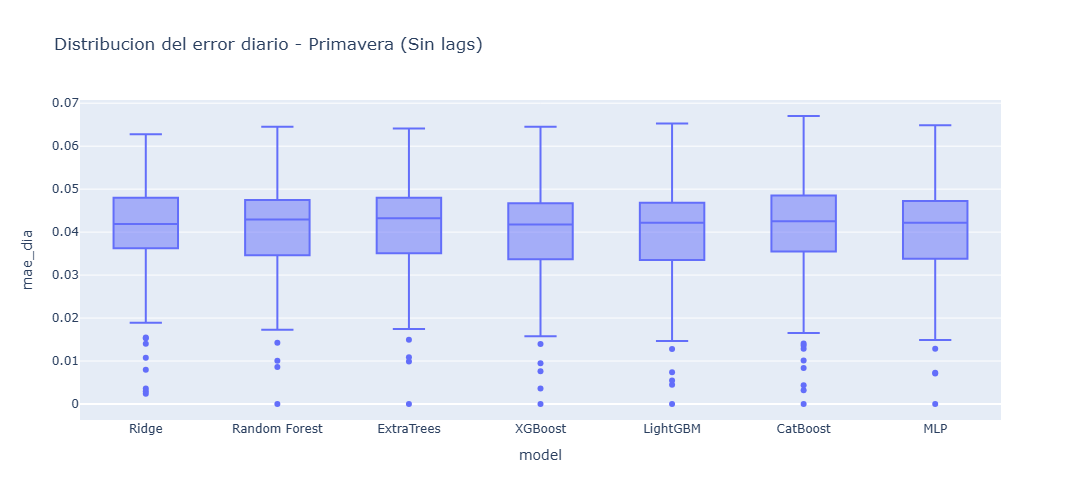

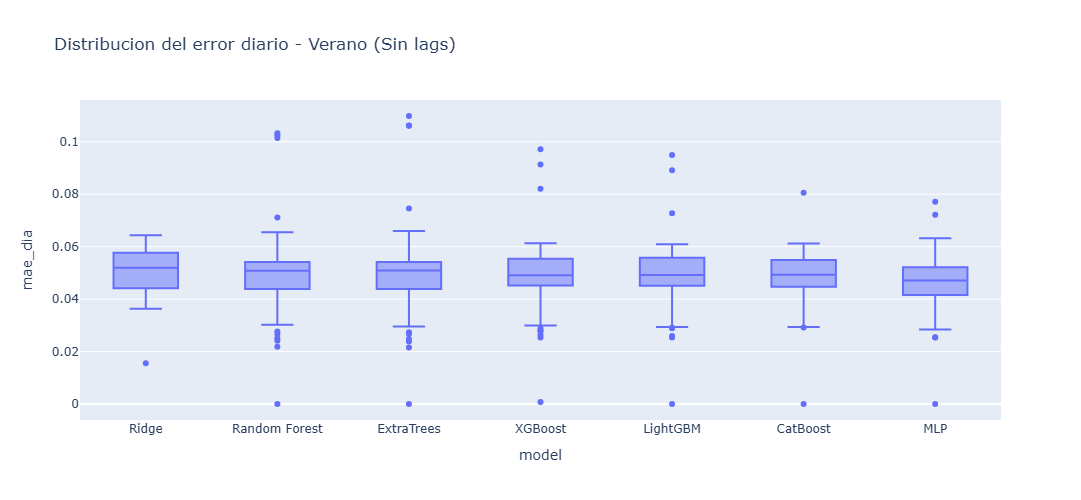

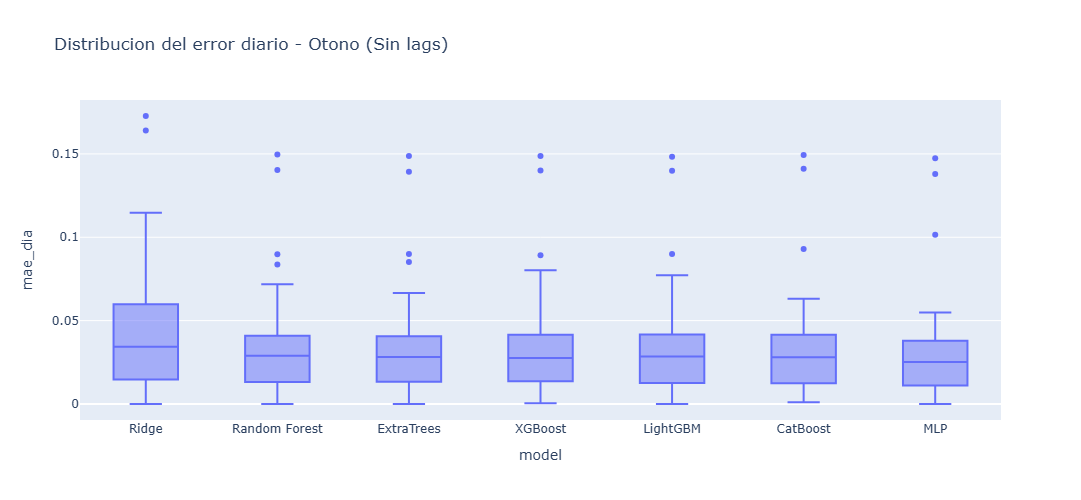

In [10]:
for tipo, models_dict, df_base, feats in [
    ("Con lags",  models_lag,   df_lag,   feat_lag),
    ("Sin lags",  models_nolag, df_nolag, feat_nolag),
]:
    for season, p in SEASONS.items():
        df_s = df_base[
            (df_base["id_planta"] == "LECA1") &
            (df_base["timestamp"] >= p["start"]) &
            (df_base["timestamp"] <= p["end"])
        ].copy()
        if df_s.empty:
            continue

        df_s["date"] = df_s["timestamp"].dt.date
        df_plot = []
        for name, model in models_dict.items():
            df_tmp = df_s.copy()
            df_tmp["abs_error"] = (df_s[TARGET].values - model.predict(df_s[feats])).clip(min=0)
            daily = df_tmp.groupby("date")["abs_error"].mean().reset_index(name="mae_dia")
            daily["model"] = name
            df_plot.append(daily)

        fig = px.box(
            pd.concat(df_plot, ignore_index=True),
            x="model", y="mae_dia",
            title=f"Distribucion del error diario - {season} ({tipo})",
        )
        fig.update_layout(width=900, height=500)
        fig.show()


### 10. Guardado de resultados


In [11]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
df_seasonal.to_csv(RESULTS_DIR / "exp4_estacionalidad.csv", index=False)
print("Resultados guardados en: data/results/exp4_estacionalidad.csv")


Resultados guardados en: data/results/exp4_estacionalidad.csv


## Conclusiones del Experimento 4

1. Sin *lags* el rendimiento varia fuertemente entre estaciones. Invierno y
   Otoño presentan errores notablemente mayores, lo que indica que el modelo
   sin memoria temporal no capta la dinámica variable de estas estaciones.
2. Con *lags* la variabilidad estacional se reduce significativamente y el
   comportamiento es más uniforme a lo largo del año.
3. Los *lags* explican parte de la variabilidad estacional: no todo se debe
   a condiciones meteorológicas externas; la dependencia temporal captura
   información de la dinámica del sistema común entre estaciones.
4. Ridge es el más afectado por la estacionalidad sin *lags*: al asumir
   linealidad no puede adaptarse a cambios de régimen estacional.
5. El error horario muestra el mismo patrón en todas las estaciones:
   máximo al mediodia, independientemente del nivel de producción estacional.

**Archivo de salida:** `data/results/exp4_estacionalidad.csv`  
**Siguiente paso:** Experimento 5 - predicción a distintos horizontes temporales.
